# Лабораторная работа №2
### Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

#### Введение
В качестве набора данных будем использовать датасет "Wine reviews". В датасете содержится информация о сортах вин. 
Ссылка на датасет: https://www.kaggle.com/datasets/zynicide/wine-reviews
Датасет содержит следующие поля.

1. **id**           - номер по списку
2. **country**      - страна производства
3. **description**  - несколько фраз от сомелье, описывающих вкус, запах, внешний вид, ощущения от вина и так далее
4. **designation**  - виноградник на территории винодельни, откуда собирают виноград, из которого делают вино
5. **points**       - количество баллов, на которые любители вина оценили вино по шкале от 1 до 100 (хотя они говорят, что публикуют отзывы только винах, которые набрали >80 баллов)
6. **price**        - стоимость бутылки вина
7. **province**     - провинция или штат, из которого произведено вино
8. **region_1**     - винодельческий регион в провинции или штате (например, Напа)
9. **region_2**     - иногда в пределах винодельческого региона указываются более конкретные регионы (например, Резерфорд в долине Напа), но иногда это значение может быть пустым
10. **variety**     - сорт винограда, используемый для производства вина (например, Пино Нуар)
11. **winery**      - винодельня, на которой производилось это вино

Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
- обработку пропусков в данных;
- кодирование категориальных признаков;
- масштабирование данных.

### Импорт библиотек
Импортируем библиотеки с помощью команды import. 

In [199]:
%matplotlib notebook

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.stats.multitest

In [201]:
from scipy import stats

### Загрузка и очистка данных
Загрузим файлы датасета в помощью библиотеки Pandas. Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.


In [202]:
df = pd.read_csv('wine_views.csv')
df.head(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
5,5,Spain,"Deep, dense and pure from the opening bell, th...",Numanthia,95,73.0,Northern Spain,Toro,NaN,Tinta de Toro,Numanthia
6,6,Spain,Slightly gritty black-fruit aromas include a s...,San Román,95,65.0,Northern Spain,Toro,NaN,Tinta de Toro,Maurodos
7,7,Spain,Lush cedary black-fruit aromas are luxe and of...,Carodorum Único Crianza,95,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
8,8,US,This re-named vineyard was formerly bottled as...,Silice,95,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström
9,9,US,The producer sources from two blocks of the vi...,Gap's Crown Vineyard,95,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm


In [203]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(df.isna().sum())

Пропуски до обработки:
Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64


In [204]:
# Размер датасета - 150930 строк, 11 колонок
df.shape

(150930, 11)

In [205]:
total_count = df.shape[0]
print('Всего строк: {}'.format(total_count))
# Список колонок
# df.columns
# Список колонок с типами данных
df.dtypes

Всего строк: 150930


Unnamed: 0       int64
country         object
description     object
designation     object
points           int64
price          float64
province        object
region_1        object
region_2        object
variety         object
winery          object
dtype: object

In [206]:
# Основные статистики для категориальных полей
print(df.select_dtypes('object').describe())

       country                                        description designation  \
count   150925                                             150930      105195   
unique      48                                              97821       30621   
top         US  A little bit funky and unsettled when you pop ...     Reserve   
freq     62397                                                  6        2752   

          province     region_1       region_2     variety           winery  
count       150925       125870          60953      150930           150930  
unique         455         1236             18         632            14810  
top     California  Napa Valley  Central Coast  Chardonnay  Williams Selyem  
freq         44508         6209          13057       14482              374  


In [207]:
# Основные статистики для числовых полей
print(df.describe())

          Unnamed: 0         points          price
count  150930.000000  150930.000000  137235.000000
mean    75464.500000      87.888418      33.131482
std     43569.882402       3.222392      36.322536
min         0.000000      80.000000       4.000000
25%     37732.250000      86.000000      16.000000
50%     75464.500000      88.000000      24.000000
75%    113196.750000      90.000000      40.000000
max    150929.000000     100.000000    2300.000000


In [208]:
# Определим уникальные значения для категориальных полей
fields = ['country', 'province', 'region_1', 'region_2', 'variety']

# Используем цикл для итерации по полям и вывода уникальных значений
for field in fields:
    print(f"Уникальные значения для поля '{field}':")
    print(df[field].unique())
    print("-" * 30) # Просто для визуального разделения результатов

Уникальные значения для поля 'country':
['US' 'Spain' 'France' 'Italy' 'New Zealand' 'Bulgaria' 'Argentina'
 'Australia' 'Portugal' 'Israel' 'South Africa' 'Greece' 'Chile' 'Morocco'
 'Romania' 'Germany' 'Canada' 'Moldova' 'Hungary' 'Austria' 'Croatia'
 'Slovenia' nan 'India' 'Turkey' 'Macedonia' 'Lebanon' 'Serbia' 'Uruguay'
 'Switzerland' 'Albania' 'Bosnia and Herzegovina' 'Brazil' 'Cyprus'
 'Lithuania' 'Japan' 'China' 'South Korea' 'Ukraine' 'England' 'Mexico'
 'Georgia' 'Montenegro' 'Luxembourg' 'Slovakia' 'Czech Republic' 'Egypt'
 'Tunisia' 'US-France']
------------------------------
Уникальные значения для поля 'province':
['California' 'Northern Spain' 'Oregon' 'Provence' 'Northeastern Italy'
 'Southwest France' 'Kumeu' 'Washington' 'Bulgaria' 'Tuscany'
 'France Other' 'Rhône Valley' 'Galicia' 'Andalucia' 'Idaho' 'Burgundy'
 'Loire Valley' 'New York' 'Mendoza Province' 'Victoria' 'Alentejano'
 'Piedmont' 'Alentejo' 'Champagne' 'Upper Galilee' 'Beira Atlantico'
 'Veneto' 'Douro' '

# 1) Обработка пропусков в данных
### 1.1) Простые стратегии - удаление или заполнение нулями

In [209]:
df_copy = df.copy()
df_copy.head(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
5,5,Spain,"Deep, dense and pure from the opening bell, th...",Numanthia,95,73.0,Northern Spain,Toro,NaN,Tinta de Toro,Numanthia
6,6,Spain,Slightly gritty black-fruit aromas include a s...,San Román,95,65.0,Northern Spain,Toro,NaN,Tinta de Toro,Maurodos
7,7,Spain,Lush cedary black-fruit aromas are luxe and of...,Carodorum Único Crianza,95,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
8,8,US,This re-named vineyard was formerly bottled as...,Silice,95,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström
9,9,US,The producer sources from two blocks of the vi...,Gap's Crown Vineyard,95,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm


In [210]:
# Удаление колонок, содержащих пустые значения
df_new_1 = df_copy.dropna(axis=1, how='any')
(df.shape, df_new_1.shape)

((150930, 11), (150930, 5))

In [211]:
# Удаление строк, содержащих пустые значения
df_new_2 = df_copy.dropna(axis=0, how='any')
(df.shape, df_new_2.shape)

((150930, 11), (39241, 11))

In [212]:
# Заполнение пустых значений (некорректно занулять значение категориального поля)
# Столбец region_2 может содержать пустые значения
categorical_cols = ['country', 'province', 'region_1', 'variety'] 
df_new_3 = df_copy.copy()
# Заполняем пропущенные значения в категориальных столбцах наиболее часто встречающимся значением (модой)
for col in categorical_cols:
    if col in df_new_3.columns:
        most_frequent_value = df_new_3[col].mode()[0] 
        df_new_3[col] = df_new_3[col].fillna(most_frequent_value)
    else:
        print(f"Столбец '{col}' не найден в датасете.") 

# Проверяем, что пропущенных значений больше нет в категориальных столбцах
print(df_new_3[categorical_cols].isnull().sum()) 

country     0
province    0
region_1    0
variety     0
dtype: int64


In [213]:
# Выводим первые несколько строк, чтобы убедиться, что все в порядке
df_new_3.head(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
5,5,Spain,"Deep, dense and pure from the opening bell, th...",Numanthia,95,73.0,Northern Spain,Toro,NaN,Tinta de Toro,Numanthia
6,6,Spain,Slightly gritty black-fruit aromas include a s...,San Román,95,65.0,Northern Spain,Toro,NaN,Tinta de Toro,Maurodos
7,7,Spain,Lush cedary black-fruit aromas are luxe and of...,Carodorum Único Crianza,95,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
8,8,US,This re-named vineyard was formerly bottled as...,Silice,95,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström
9,9,US,The producer sources from two blocks of the vi...,Gap's Crown Vineyard,95,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm


### 1.2) "Внедрение значений" - импьютация (imputation)

#### Обработка пропусков в числовых данных

In [214]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in df.columns:
    # Количество пустых значений 
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка price. Тип данных float64. Количество пустых значений 13695, 9.07%.


In [215]:
# Фильтр по колонкам с пропущенными значениями
df_num = df[num_cols]
df_num.head(10)

,price
0,235.0
1,110.0
2,90.0
3,65.0
4,66.0
5,73.0
6,65.0
7,110.0
8,65.0
9,60.0


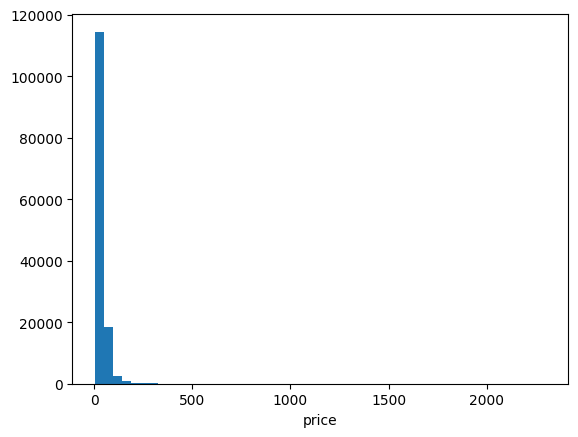

In [216]:
%matplotlib inline
# Гистограмма по признакам
for col in df_num:
    plt.hist(df[col], 50)
    plt.xlabel(col)
    plt.show()

In [217]:
data_num_price = df_num[['price']]
data_num_price.head(10)

,price
0,235.0
1,110.0
2,90.0
3,65.0
4,66.0
5,73.0
6,65.0
7,110.0
8,65.0
9,60.0


In [218]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_price)
mask_missing_values_only

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [219]:
# С помощью класса SimpleImputer можно проводить импьютацию различными показателями центра распределения
strategies=['mean', 'median', 'most_frequent']

In [220]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_price)
    return data_num_imp[mask_missing_values_only]
    
strategies[0], test_num_impute(strategies[0])

('mean',
 array([33.13148249, 33.13148249, 33.13148249, ..., 33.13148249,
        33.13148249, 33.13148249]))

In [221]:
strategies[1], test_num_impute(strategies[1])

('median', array([24., 24., 24., ..., 24., 24., 24.]))

In [222]:
strategies[2], test_num_impute(strategies[2])

('most_frequent', array([20., 20., 20., ..., 20., 20., 20.]))

In [223]:
# Более сложная функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]
    
df[['price']].describe()

,price
count,137235.000000
mean,33.131482
std,36.322536
min,4.000000
25%,16.000000
50%,24.000000
75%,40.000000
max,2300.000000


In [224]:
test_num_impute_col(df, 'price', strategies[0])

('price',
 'mean',
 13695,
 np.float64(33.13148249353299),
 np.float64(33.13148249353299))

In [225]:
test_num_impute_col(df, 'price', strategies[1])

('price', 'median', 13695, np.float64(24.0), np.float64(24.0))

In [226]:
test_num_impute_col(df, 'price', strategies[2])

('price', 'most_frequent', 13695, np.float64(20.0), np.float64(20.0))

In [227]:
df_itog = df.copy()
imp_num = SimpleImputer(strategy='most_frequent')
df_itog = pd.DataFrame(imp_num.fit_transform(df_itog), columns=df_itog.columns)

df_itog.head(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,Central Coast,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,Central Coast,Provence red blend,Domaine de la Bégude
5,5,Spain,"Deep, dense and pure from the opening bell, th...",Numanthia,95,73.0,Northern Spain,Toro,Central Coast,Tinta de Toro,Numanthia
6,6,Spain,Slightly gritty black-fruit aromas include a s...,San Román,95,65.0,Northern Spain,Toro,Central Coast,Tinta de Toro,Maurodos
7,7,Spain,Lush cedary black-fruit aromas are luxe and of...,Carodorum Único Crianza,95,110.0,Northern Spain,Toro,Central Coast,Tinta de Toro,Bodega Carmen Rodríguez
8,8,US,This re-named vineyard was formerly bottled as...,Silice,95,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström
9,9,US,The producer sources from two blocks of the vi...,Gap's Crown Vineyard,95,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm


In [228]:
print(df_itog.isnull().sum()) 

Unnamed: 0     0
country        0
description    0
designation    0
points         0
price          0
province       0
region_1       0
region_2       0
variety        0
winery         0
dtype: int64


# 2) Кодирование категориальных признаков

#### 2.1) Обработка пропусков в категориальных данных

In [229]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in df.columns:
    # Количество пустых значений 
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка country. Тип данных object. Количество пустых значений 5, 0.0%.
Колонка designation. Тип данных object. Количество пустых значений 45735, 30.3%.
Колонка province. Тип данных object. Количество пустых значений 5, 0.0%.
Колонка region_1. Тип данных object. Количество пустых значений 25060, 16.6%.
Колонка region_2. Тип данных object. Количество пустых значений 89977, 59.62%.


In [230]:
data = df.copy()
temp_data = data[['country']]
temp_data.head(10)

,country
0,US
1,Spain
2,US
3,US
4,France
5,Spain
6,Spain
7,Spain
8,US
9,US


In [231]:
temp_data['country'].unique()

array(['US', 'Spain', 'France', 'Italy', 'New Zealand', 'Bulgaria',
       'Argentina', 'Australia', 'Portugal', 'Israel', 'South Africa',
       'Greece', 'Chile', 'Morocco', 'Romania', 'Germany', 'Canada',
       'Moldova', 'Hungary', 'Austria', 'Croatia', 'Slovenia', nan,
       'India', 'Turkey', 'Macedonia', 'Lebanon', 'Serbia', 'Uruguay',
       'Switzerland', 'Albania', 'Bosnia and Herzegovina', 'Brazil',
       'Cyprus', 'Lithuania', 'Japan', 'China', 'South Korea', 'Ukraine',
       'England', 'Mexico', 'Georgia', 'Montenegro', 'Luxembourg',
       'Slovakia', 'Czech Republic', 'Egypt', 'Tunisia', 'US-France'],
      dtype=object)

In [232]:
print(temp_data['country'].isnull().sum())

5


In [233]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(temp_data)
data_imp2 = pd.DataFrame(data_imp2, columns = temp_data.columns)
print(data_imp2['country'].isnull().sum())

0


In [234]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_imp3 = imp3.fit_transform(temp_data)
data_imp3 = pd.DataFrame(data_imp3, columns = temp_data.columns)
print(data_imp3['country'].isnull().sum())

0


In [235]:
data_imp3['country'].unique()

array(['US', 'Spain', 'France', 'Italy', 'New Zealand', 'Bulgaria',
       'Argentina', 'Australia', 'Portugal', 'Israel', 'South Africa',
       'Greece', 'Chile', 'Morocco', 'Romania', 'Germany', 'Canada',
       'Moldova', 'Hungary', 'Austria', 'Croatia', 'Slovenia', 'NA',
       'India', 'Turkey', 'Macedonia', 'Lebanon', 'Serbia', 'Uruguay',
       'Switzerland', 'Albania', 'Bosnia and Herzegovina', 'Brazil',
       'Cyprus', 'Lithuania', 'Japan', 'China', 'South Korea', 'Ukraine',
       'England', 'Mexico', 'Georgia', 'Montenegro', 'Luxembourg',
       'Slovakia', 'Czech Republic', 'Egypt', 'Tunisia', 'US-France'],
      dtype=object)

In [236]:
data_imp3[data_imp3['country'] == 'NA'].size

5

### 2.2) Преобразование категориальных признаков в числовые

In [237]:
data_enc = pd.DataFrame({'c1':data_imp2['country']})
data_enc

,c1
0,US
1,Spain
2,US
3,US
4,France
...,...
150925,Italy
150926,France
150927,Italy
150928,France


#### Кодирование категорий целочисленными значениями (label encoding)

##### Использование LabelEncoder

In [238]:
from sklearn.preprocessing import LabelEncoder
data_enc['c1'].unique()

array(['US', 'Spain', 'France', 'Italy', 'New Zealand', 'Bulgaria',
       'Argentina', 'Australia', 'Portugal', 'Israel', 'South Africa',
       'Greece', 'Chile', 'Morocco', 'Romania', 'Germany', 'Canada',
       'Moldova', 'Hungary', 'Austria', 'Croatia', 'Slovenia', 'India',
       'Turkey', 'Macedonia', 'Lebanon', 'Serbia', 'Uruguay',
       'Switzerland', 'Albania', 'Bosnia and Herzegovina', 'Brazil',
       'Cyprus', 'Lithuania', 'Japan', 'China', 'South Korea', 'Ukraine',
       'England', 'Mexico', 'Georgia', 'Montenegro', 'Luxembourg',
       'Slovakia', 'Czech Republic', 'Egypt', 'Tunisia', 'US-France'],
      dtype=object)

In [239]:
le = LabelEncoder()
data_enc_le = le.fit_transform(data_enc['c1'])

In [240]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(['Albania', 'Argentina', 'Australia', 'Austria',
       'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile',
       'China', 'Croatia', 'Cyprus', 'Czech Republic', 'Egypt', 'England',
       'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'India',
       'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Luxembourg',
       'Macedonia', 'Mexico', 'Moldova', 'Montenegro', 'Morocco',
       'New Zealand', 'Portugal', 'Romania', 'Serbia', 'Slovakia',
       'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Switzerland',
       'Tunisia', 'Turkey', 'US', 'US-France', 'Ukraine', 'Uruguay'],
      dtype=object)

In [241]:
data_enc_le

array([44, 40, 44, ..., 22, 15, 22])

In [242]:
np.unique(data_enc_le)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47])

##### Использование OrdinalEncoder

In [243]:
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['country']]
data_oe.head()

,country
0,US
1,Spain
2,US
3,US
4,France


In [244]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['US'],
       ['Spain'],
       ['US'],
       ...,
       ['Italy'],
       ['France'],
       ['Italy']], dtype=object)

In [245]:
oe = OrdinalEncoder()
data_enc_oe = oe.fit_transform(data_oe_filled)
data_enc_oe

array([[45.],
       [41.],
       [45.],
       ...,
       [22.],
       [15.],
       [22.]])

In [246]:
# Уникальные значения 1 признака
np.unique(data_enc_oe[:, 0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48.])

In [247]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Albania', 'Argentina', 'Australia', 'Austria',
        'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile',
        'China', 'Croatia', 'Cyprus', 'Czech Republic', 'Egypt', 'England',
        'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'India',
        'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Luxembourg',
        'Macedonia', 'Mexico', 'Moldova', 'Montenegro', 'Morocco', 'NA',
        'New Zealand', 'Portugal', 'Romania', 'Serbia', 'Slovakia',
        'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Switzerland',
        'Tunisia', 'Turkey', 'US', 'US-France', 'Ukraine', 'Uruguay'],
       dtype=object)]

In [248]:
# Обратное преобразование
oe.inverse_transform(data_enc_oe)

array([['US'],
       ['Spain'],
       ['US'],
       ...,
       ['Italy'],
       ['France'],
       ['Italy']], dtype=object)

##### Проблемы использования LabelEncoder и OrdinalEncoder
Необходимо отметить, что LabelEncoder и OrdinalEncoder могут использоваться только для категориальных признаков в номинальных шкалах
(для которых отсутствует порядок), например города, страны, названия рек и т.д.

Это связано с тем, что задать какой-либо порядок при кодировании с помощью LabelEncoder и OrdinalEncoder невозможно, они сортируют 
категории в лексикографическом порядке.

При этом кодирование целыми числами создает фиктивное отношение порядка (1 < 2 < 3 < ...) которого не было в исходных номинальных шкалах. 
Данное отношение порядка может негативно повлиять на построение модели машинного обучения.

Плюсы и минусы использования LabelEncoder и OrdinalEncoder:
LabelEncoder:
1. Вход: Один столбец
2. Назначение: В основном целевая переменная
3. Обработка: Автоматическое присвоение номеров
4. Множественные столбцы: Требует обработки каждого столбца отдельно		

OrdinalEncoder:
1. Матрица (DataFrame или NumPy array)
2. Назначение: В основном признаки (нецелевые)
3. Обработка: Учет порядка (если задан)
4. Множественные выборы: Может обрабатывать сразу несколько столбцов

Пример, когда OrdinalEncoder лучше, чем LabelEncoder. Используем случай, когда важен порядок.

Возьмем пример с размерами одежды и странами. Если мы хотим взять упорядочить страны, то нам не важен их порядок, поэтому любым странам может соответствовать любые индексы. В таком случае воспользуемся LabelEncoder.

В случае с размерами одежды лучше использовать OrdinalEncoder, так как размеры это не просто названия, но они еще и упорядочены. То есть XS->S->M->L->XL


In [258]:
# Пример для размеров одежды
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

data_clothes = {'Размер': ['M', 'XS', 'L', 'S', 'XL', 'M']}
df_clothes = pd.DataFrame(data_clothes)

mapping = [['XS', 'S', 'M', 'L', 'XL']]

encoder = OrdinalEncoder(categories=mapping)
df_clothes['КодРазмера'] = encoder.fit_transform(df_clothes[['Размер']])

print(df_clothes)

  Размер  КодРазмера
0      M         2.0
1     XS         0.0
2      L         3.0
3      S         1.0
4     XL         4.0
5      M         2.0


In [261]:
# Пример для стран
np.unique(data_enc_oe[:, 0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48.])

In [262]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Albania', 'Argentina', 'Australia', 'Austria',
        'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile',
        'China', 'Croatia', 'Cyprus', 'Czech Republic', 'Egypt', 'England',
        'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'India',
        'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Luxembourg',
        'Macedonia', 'Mexico', 'Moldova', 'Montenegro', 'Morocco', 'NA',
        'New Zealand', 'Portugal', 'Romania', 'Serbia', 'Slovakia',
        'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Switzerland',
        'Tunisia', 'Turkey', 'US', 'US-France', 'Ukraine', 'Uruguay'],
       dtype=object)]

# 3) Масштабирование данных

Термины "масштабирование" и "нормализация" часто используются как синонимы, но это неверно. Масштабирование предполагает изменение диапазона измерения величины, а нормализация - изменение распределения этой величины. В этом разделе рассматривается только масштабирование.

Если признаки лежат в различных диапазонах, то необходимо их нормализовать. Как правило, применяют два подхода:
1. MinMax масштабирование (В этом случае значения лежат в диапазоне от 0 до 1)
2. Масштабирование данных на основе Z-оценки (В этом случае большинство значений попадает в диапазон от -3 до 3)

In [254]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

### 3.1) MinMax масштабирование

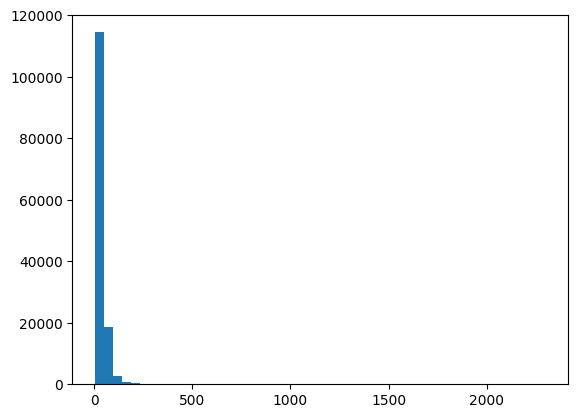

In [255]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['price']])
plt.hist(data['price'], 50)
plt.show()

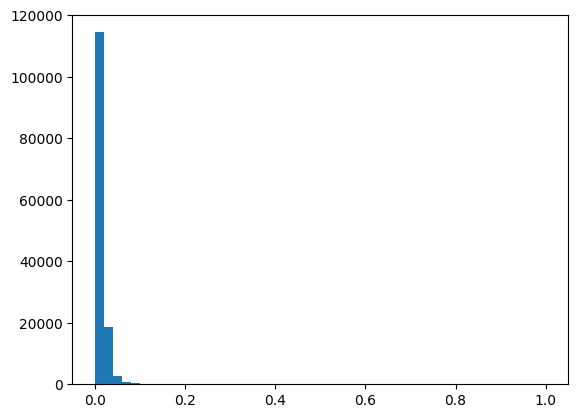

In [256]:
# В этом случае значения лежат в диапазоне от 0 до 1
plt.hist(sc1_data, 50)
plt.show()

### 3.2) Масштабирование данных на основе Z-оценки

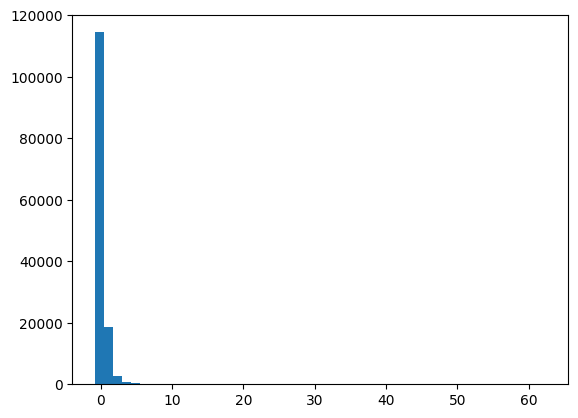

In [257]:
# В этом случае большинство значений попадает в диапазон от -3 до 3
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['price']])
plt.hist(sc2_data, 50)
plt.show()

**Масштабирование данных** - это преобразование числовых признаков, чтобы привести их к определенному диапазону или распределению. Это нужно, чтобы признаки с разными единицами измерения или масштабами не вносили непропорциональный вклад в модели машинного обучения.

Виды масштабирования:
1. **MinMax Scaling**: Приводит значения признаков к диапазону от 0 до 1. Работает, вычитая минимум и деля на разницу между максимумом и минимумом. Подходит, когда важно сохранить отношения между данными и когда нет выбросов.
2. **Z-score Standardization** (Standard Scaling): Преобразует значения, чтобы они имели среднее значение 0 и стандартное отклонение 1. Работает, вычитая среднее и деля на стандартное отклонение. Хорошо, когда важна форма распределения (например, для линейных моделей) и когда есть выбросы. Большинство значений оказываются в диапазоне от -3 до 3, но это не гарантируется.